# The Kernel Distribution Estimation (KDE)

The KDE is a non-parametric method to estimate the probability density function (pdf) of a random variable based on kernels as weights. 

## Definition

Let $\mathbf{x} = (x_1,x_2,x_3, /dots)$ be independent and identically distributied samples drawn from an univariate distribution with unknown density $f$ at any point $x$. Its KDE is defined as

$$\hat{f}_h(x) = \frac{1}{nh} \sum_{j=1}^{n} K{\frac{(x-x_j)}{h}}$$

with $K$ being kernel (non-negative function) and $h>0$ is a smoothing parameter called the bandwidth. 

### Kernel Choice

Commonly used Kernel functions are the uniform, normal, and Epanechnikov distributions.

### Bandwidth Selection

The bandwidth $h$ of the kernel is a free parameter that has strong influence on the resulting estimate. The larger $h$ the more "smooth" the curve will be. Small $h$ leads to low bias and high variance, which captures noise but risks overfitting. Large $h$ leads to high bias and low variance which can miss structure and overfit. 

#### Theoritical Bandwidth Selection

Theoritically, we want to minimize 

$$MISE(h) = \mathbb{E} \!\left[ \int {(\hat{f}_h(x) - f(x))^2} \,dx \right]$$

with asymtotic expansion giving

$$MISE(h) \approx \text{Bias}^2 + \text{Variance}$$

with $\text{Bias}^2$ growing like $h$^4 and $\text{Variance}$ shrinking like $\frac{1}{nh}$. Minimizing gives $h \sim n^{-1/5}$.

### Selecting Bandwidth For Real Now

#### Silverman's Rule:

For a Guassian kernel 
$$h = 0.9 \min(\sigma, \tfrac{\text{IQR}}{1.34}) n^{-1/5}$$
is a fast way to choose h. Assumes roughly normal data though.

#### Cross-Validation

Choose $h$ that minimizes an estimate of $\int (\hat f_h - f)^2$. Typically done with leave-one-out likelihood:

$$\text{CV}(h) = \frac{1}{n} \sum_{i=1}^n \log \hat f_{-i,h}(X_i)$$
More adaptive, unstable for small samples, computationally heavier.

#### Plug in

Try out $h$ until it looks right!

## Conclusion

Eventually, this will be how we build a weighted VR complex essentially saying that $\varepsilon_i$ depends on how dense the data is near $x_i$.



# Normal Kernel Example

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def normal_kde_1d(x: np.ndarray, grid: np.ndarray, h: float) -> np.ndarray:
    #1D Gaussian (Normal) KDE with fixed bandwidth.
    #Returns: (m,) array of density estimates

    x = np.asarray(x, dtype=float).reshape(-1)
    grid = np.asarray(grid, dtype=float).reshape(-1)

    if h <= 0:
        raise ValueError("Bandwidth h must be > 0.")

    n = x.size

    # Normalization constant:
    # 1 / (n * sqrt(2π) * h)
    const = 1.0 / (n * np.sqrt(2.0 * np.pi) * h)

    # Compute all differences between grid points and data points
    diff = grid[:, None] - x[None, :]   # shape (m, n)

    # Apply Gaussian kernel
    kernel_vals = np.exp(-(diff ** 2) / (2.0 * h ** 2))

    # Sum over data points
    density = const * np.sum(kernel_vals, axis=1)

    return density


def plot_kde(x: np.ndarray, h: float, kernel: str = "gaussian", grid_points: int = 400):
    # Plot histogram + KDE curve + rug plot

    x = np.asarray(x, dtype=float).reshape(-1)

    pad = 0.1 * (x.max() - x.min())
    grid = np.linspace(x.min() - pad, x.max() + pad, grid_points)

    dens = kde_1d(x, grid, h, kernel=kernel)

    plt.figure()
    plt.hist(x, bins=30, density=True, alpha=0.3)
    plt.plot(grid, dens, linewidth=2)

    ymin, ymax = plt.ylim()
    rug_y = ymin + 0.02 * (ymax - ymin)
    plt.plot(x, np.full_like(x, rug_y), "|", markersize=10)

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title(f"{kernel.capitalize()} KDE (h={h})")
    plt.show()

## Examples

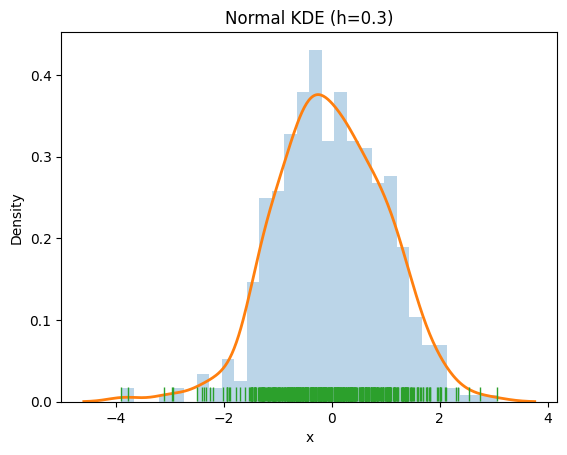

In [30]:
# Actual Normal Data
rng = np.random.default_rng(0)
x = rng.normal(0,1,size = 500)

plot_kde_normal(x, h = 0.3)

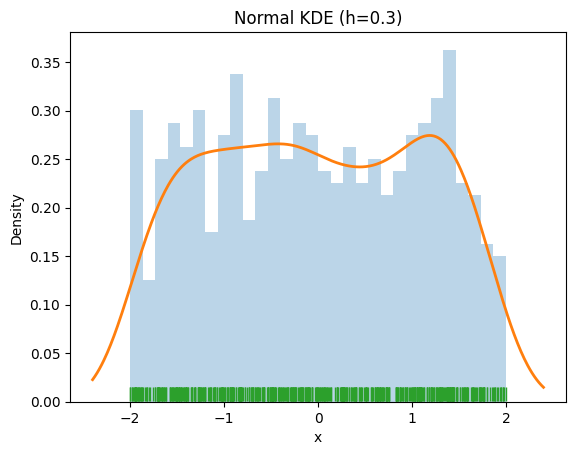

In [31]:
# Uniform

x = rng.uniform(-2,2, size = 600)
plot_kde_normal(x, h=0.3)

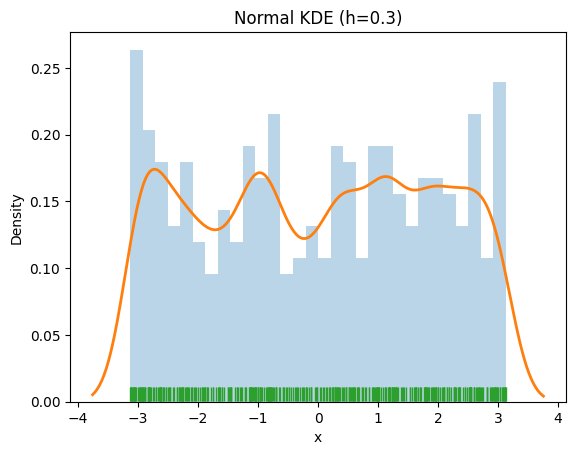

In [32]:
# Data on S^1
theta = rng.uniform(-np.pi, np.pi, size = 400)
plot_kde_normal(theta, h = 0.3)

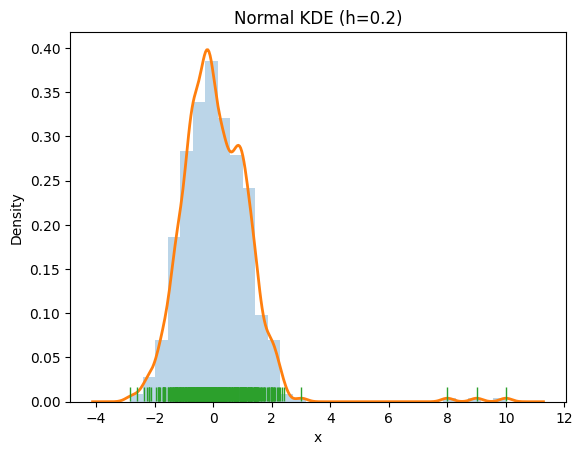

In [38]:
# Data with Strong Outliers

x = np.concatenate([
    rng.normal(0, 1, 500),
    np.array([8, 9, 10])  # extreme outliers
])

plot_kde_normal(x, h=0.2)